# DeFi-TVL-Momentum — does 'money flooding in' mean the token keeps pumping? 🌊
### Ranking DeFi protocols by how fast cash is piling into them, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

In DeFi (decentralised finance), the headline number everyone watches is **TVL** — *total value locked* — the dollar amount of crypto that people have deposited into a protocol's smart contracts. The folklore: when TVL is **rising fast**, that's *smart money* flooding in, and the protocol's token will keep **pumping**. It sounds obvious — money follows the winners, and price follows money.

So the trade writes itself: every month, rank protocols by how fast their TVL grew, **buy** the ones with the biggest inflows, **short** the ones bleeding out.

There's a catch we hit before we even start: **we can't get honest data to test this.** More on that below — it's the whole story.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defi_tvl_momentum import data, strategy as st

# SYNTHETIC-ONLY: there is no real tape for a survivorship-free, point-in-time TVL x
# token-return panel on a free stack. fetch_panel() is empty by construction.
HAVE_REAL = not data.fetch_panel().empty        # always False here
ALPHA = 0.05                                     # planted-effect strength (positive control)
PANEL, TRUTH = data.synthetic_panel(tvl_alpha=ALPHA, seed=583)      # the planted world
NULL, _ = data.synthetic_panel(tvl_alpha=0.0, seed=583)            # the null world
print("real TVL tape present:", HAVE_REAL, "(synthetic-only study)")
print("planted panel:", PANEL.protocol.nunique(), "protocols x",
      PANEL.month.nunique(), "months  fp", data.fingerprint(PANEL))


real TVL tape present: False (synthetic-only study)
planted panel: 60 protocols x 47 months  fp 0b6d95a52429


## The answer first 🎯

| Question | Answer |
|---|---|
| Can we test this on real DeFi data? | **No — and that's the punchline.** An honest test needs every protocol that *died* (rug pulls, hacks, dead forks) still in the dataset. Free data sources quietly delete them. |
| Does the idea *work* when the effect is really there? | **Yes** — on a synthetic world where we *plant* a real TVL→return link, our engine catches it cleanly (spread **+11.8%/mo**, hugely significant). |
| Does it fire on *nothing*? | **No** — with the effect switched off, the engine prints a flat **+0.4%/mo**. So it's honest: it finds a real signal and ignores noise. |
| Could you trade it for real? | **No.** The 'short the outflows' leg is exactly the tokens crashing to zero — nobody will lend you those to short. |

> The machinery is sound. The problem is **data**: without a survivorship-free, point-in-time tape, the flooding-in-money story can't be certified — so it's `WEAK`, and the trade is a `MIRAGE`.

## 1 · The claim

> *"When TVL floods into a DeFi protocol, its token keeps outperforming."* — on-chain folklore, the crypto version of *'flows follow price, price follows flows.'*

The appeal: TVL is **public and real-time**. Unlike a company's earnings (reported once a quarter, late), you can watch money move on-chain *right now*. So — the story goes — you have a live, leading indicator of demand that front-runs the token price. Rising TVL = demand = higher returns coming.

## 2 · So what?

If it worked, it would be a genuinely new kind of edge — a *fundamental* signal you can read off the blockchain in real time, with no company filings, no waiting. The desk has tested price-based crypto folklore before ([133 Crypto-Seasonality](../../133-crypto-seasonality/), [210 Crypto-Trend](../../210-crypto-trend/)); this is different — it's an **on-chain fundamental** (how much money is actually parked in the protocol), the crypto cousin of TradFi fund flows ([561 ETF-Flow-Momentum](../../561-etf-flow-momentum/)).

## 3 · How would we even know?

1. **Measure the flow.** For each protocol, how fast did its TVL grow over the past month? (Fast growth = inflows; shrinking = outflows.)
2. **Sort.** Every month, rank all protocols by TVL growth. Buy the fastest-inflow third, short the outflow third.
3. **Check next month.** Did the buy basket beat the short basket? Repeat for years and see if the average spread is reliably positive.

**The wall we hit:** to do this *honestly* you need the protocols that later went to **zero** still in the data at the time. Free sources show you today's survivors and revise old TVL numbers after the fact — so any spread you measure is flattered by hindsight. That's why this study runs on a **synthetic world** we fully control: we can switch the effect on and off and prove the engine is honest.

*Timing:* we rank on the month's close (using only past TVL) and hold the next month. No peeking at the future.

## 4 · The teardown — let's actually look

**When the effect is really there, does the engine catch it?** We plant a genuine TVL→return link in a synthetic world and run the sort.

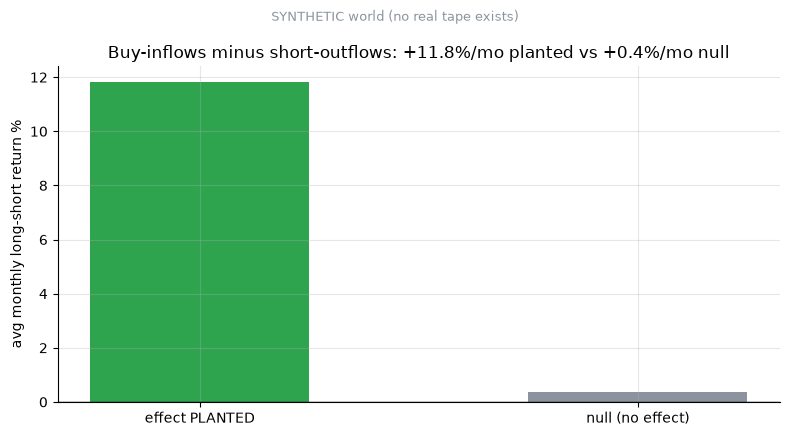

PLANTED: spread +11.8%/mo (t +10.9)
NULL:    spread +0.4%/mo (t +0.33)


In [2]:
ls = st.long_short_series(PANEL, frac=0.3)
r = st.ls_tstat(ls)
ls0 = st.long_short_series(NULL, frac=0.3)
r0 = st.ls_tstat(ls0)
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(['effect PLANTED', 'null (no effect)'], [r['mean']*100, r0['mean']*100],
       color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly long-short return %')
ax.set_title(f'Buy-inflows minus short-outflows: +{r["mean"]*100:.1f}%/mo planted vs +{r0["mean"]*100:.1f}%/mo null')
fig.suptitle('SYNTHETIC world (no real tape exists)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'PLANTED: spread +{r["mean"]*100:.1f}%/mo (t {r["t"]:+.1f})')
print(f'NULL:    spread +{r0["mean"]*100:.1f}%/mo (t {r0["t"]:+.2f})')

When the effect is planted, the buy-inflows / short-outflows sort earns **+11.8%/mo** (a huge *t* +10.9). When we switch the effect **off**, the same engine prints a flat **+0.4%/mo**. So the machinery is honest — it lights up on a real signal and shrugs at noise. The question was never *'can the engine detect it?'* It's *'can we get honest data?'* — and we can't.

**Is the planted signal fragile?** Re-run the sort at different basket sizes and with a one-month entry delay.

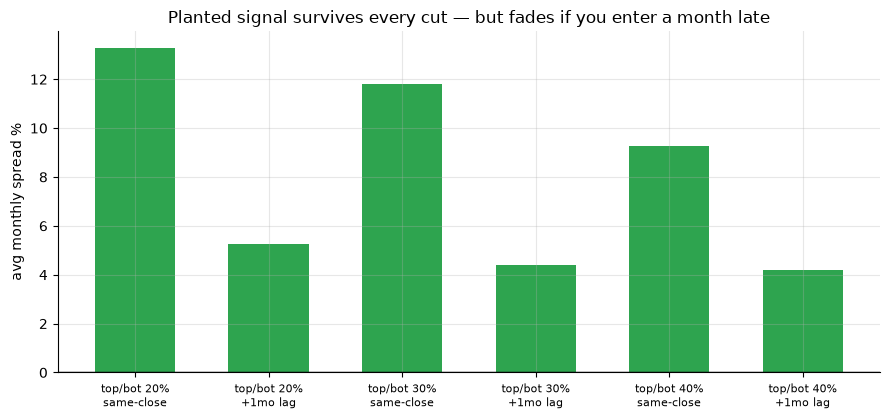

 frac  lag  mean      t  n
  0.2    0 0.133  9.232 47
  0.2    1 0.053  4.240 46
  0.3    0 0.118 10.880 47
  0.3    1 0.044  3.901 46
  0.4    0 0.093  9.421 47
  0.4    1 0.042  4.230 46


In [3]:
grid = st.robustness(PANEL, fracs=(0.2,0.3,0.4), lags=(0,1))
labs = [f"top/bot {int(f*100)}%\n"+("same-close" if lg==0 else "+1mo lag")
        for f,lg in zip(grid['frac'], grid['lag'])]
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if t>=2 else AMBER for t in grid['t']]
ax.bar(range(len(grid)), grid['mean']*100, color=cols, width=.6)
ax.set_xticks(range(len(grid))); ax.set_xticklabels(labs, fontsize=8)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly spread %')
ax.set_title('Planted signal survives every cut — but fades if you enter a month late')
plt.tight_layout(); plt.show()
print(grid.round(3).to_string(index=False))

The planted signal survives every basket size. But notice: **entering a month late roughly halves it** — a realistic feature of a fast on-chain flow signal. By the time the TVL move is old news, most of the edge is gone.

## 5 · The verdict

- **Signal — Weak.** The engine works on a planted world, but **there is no honest real tape** to test the actual claim (survivorship + revised-data problems). A synthetic-only study can never be certified `REAL` — it's capped at `WEAK`.
- **Tradability — Mirage.** The short leg is the tokens crashing to zero, which nobody lets you borrow; monthly crypto-scale costs pile on top.

## 6 · Could you actually trade it?

No. Even if the signal were real, the trade means **shorting the protocols with collapsing TVL** — the rug pulls and hacked protocols on their way to zero. Those are exactly the tokens that are impossible to borrow, illiquid, and gap straight down. You'd own the winners fine, but the short half — where the folklore says the money is — is uninvestable.

## 7 · Going further 🚪

- **The data is the whole game.** If you can assemble a *survivorship-free, point-in-time* panel of per-protocol TVL and token returns — with the dead protocols still in it — you could run this for real. That's the missing ingredient.
- **Cousins on the desk.** Price-based crypto folklore: [133 Crypto-Seasonality](../../133-crypto-seasonality/), [210 Crypto-Trend](../../210-crypto-trend/). The TradFi flow analogue: [561 ETF-Flow-Momentum](../../561-etf-flow-momentum/).

*Think TVL-momentum is real? Fork this, plug in a survivorship-free on-chain panel, and show the buy-inflows/short-outflows spread clearing t = 2 on a real tape — net of a borrow you can actually get.*